In [1]:
import numpy as np
import polars as pl
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
import polars as pl

inicial = (
    pl.scan_parquet(r"C:\Users\diogo.durao\Documents\covid_sp.parquet")
    .select([
        "paciente_idade",
        "paciente_dataNascimento",
        "paciente_enumSexoBiologico",
        "paciente_endereco_nmMunicipio",
        "paciente_endereco_uf",
        "vacina_dataAplicacao",
        "vacina_fabricante_nome",
        "vacina_nome"
    ])
    .with_columns(
        pl.col("paciente_idade").cast(pl.Int64, strict=False),
        pl.col("paciente_dataNascimento").str.to_date("%Y-%m-%d", strict=False),
        pl.col("vacina_dataAplicacao").str.to_date("%Y-%m-%d", strict=False)
    )
)

display(inicial.head(5).collect())

paciente_idade,paciente_dataNascimento,paciente_enumSexoBiologico,paciente_endereco_nmMunicipio,paciente_endereco_uf,vacina_dataAplicacao,vacina_fabricante_nome,vacina_nome
i64,date,str,str,str,date,str,str
32,1989-05-29,"""F""","""GUARULHOS""","""SP""",2022-04-05,"""JANSSEN""","""COVID-19 JANSSEN - Ad26.COV2.S"""
59,1961-09-06,"""F""","""IBITINGA""","""SP""",2021-05-31,"""ASTRAZENECA/FIOCRUZ""","""COVID-19 ASTRAZENECA/FIOCRUZ -…"
85,1936-03-09,"""M""","""SAO PAULO""","""SP""",2021-12-04,"""PFIZER""","""COVID-19 PFIZER - COMIRNATY"""
35,1985-11-22,"""M""","""SAO PAULO""","""SP""",2021-08-14,"""SINOVAC/BUTANTAN""","""COVID-19 SINOVAC/BUTANTAN - CO…"
53,1968-05-18,"""M""","""SAO PAULO""","""SP""",2021-09-14,"""PFIZER""","""COVID-19 PFIZER - COMIRNATY"""


Dados para plotagem:
         Mes  Qtd_Vacinas
0 2021-01-01       137432
1 2021-02-01       395507
2 2021-03-01       807801
3 2021-04-01      1076016
4 2021-05-01      1118104


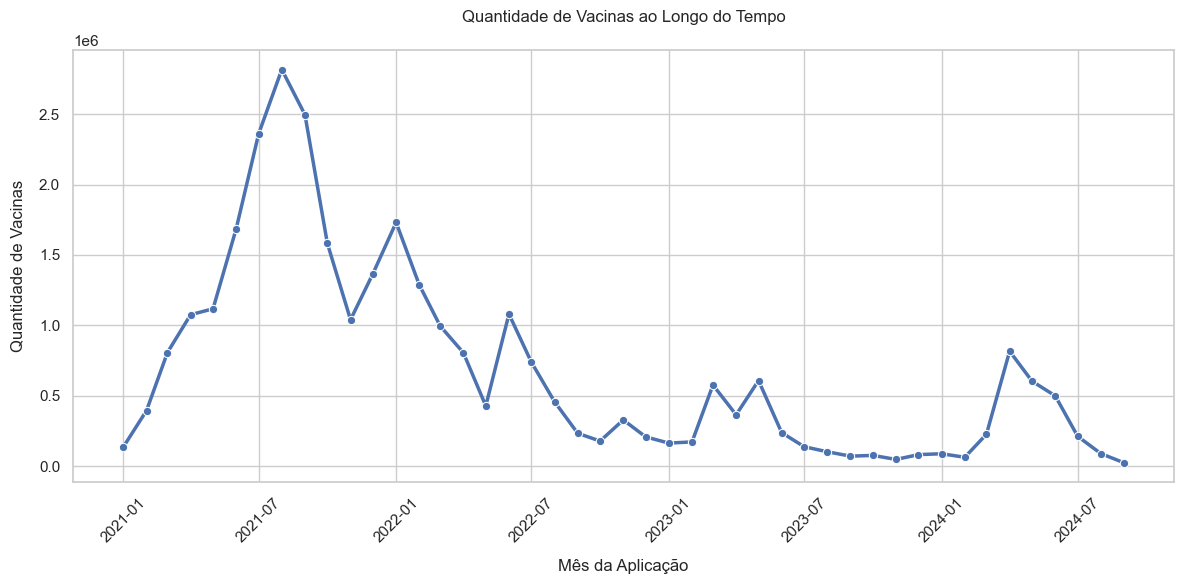

In [3]:
# Certifique-se que os dados estão corretamente agrupados

df_agrupado = inicial.filter(
pl.col("vacina_dataAplicacao") >= pl.date(2021, 1, 1)
).group_by(
pl.col("vacina_dataAplicacao").dt.truncate("1mo").alias("Mes")
).agg(
pl.len().alias("Qtd_Vacinas")
).sort("Mes").collect()

# Converter para Pandas explicitamente
df_plot = df_agrupado.to_pandas()

# Verificar os dados que serão plotados
print("Dados para plotagem:")
print(df_plot.head())

# Configurar o estilo do seaborn
sns.set_theme(style="whitegrid")

# Criar a figura e o eixo explicitamente
fig, ax = plt.subplots(figsize=(12, 6))

# Plotar usando seaborn
sns.lineplot(
data=df_plot,
x="Mes",
y="Qtd_Vacinas",
ax=ax,
marker='o',
linewidth=2.5
)

# Configurações adicionais
ax.set_title("Quantidade de Vacinas ao Longo do Tempo", pad=20)
ax.set_xlabel("Mês da Aplicação", labelpad=10)
ax.set_ylabel("Quantidade de Vacinas", labelpad=10)
ax.tick_params(axis='x', rotation=45)

# Ajustar layout para evitar cortes
plt.tight_layout()
plt.show()

In [4]:
# 1. Converter para tipo Date do Polars se necessário
if df_agrupado["Mes"].dtype != pl.Date:
    df_agrupado = df_agrupado.with_columns(
        pl.col("Mes").cast(pl.Date)
    )

# 2. Calcular usando expressões puras do Polars
df_reg = df_agrupado.with_columns(
    (pl.col("Mes").dt.year() * 12 + pl.col("Mes").dt.month() - 
     (pl.col("Mes").min().dt.year() * 12 + pl.col("Mes").min().dt.month()))
    .alias("MESES_DESDE_INICIO")
)

# 3. Verificar o resultado
print(df_reg.select(["Mes", "MESES_DESDE_INICIO"]).head())

shape: (5, 2)
┌────────────┬────────────────────┐
│ Mes        ┆ MESES_DESDE_INICIO │
│ ---        ┆ ---                │
│ date       ┆ i32                │
╞════════════╪════════════════════╡
│ 2021-01-01 ┆ 0                  │
│ 2021-02-01 ┆ 1                  │
│ 2021-03-01 ┆ 2                  │
│ 2021-04-01 ┆ 3                  │
│ 2021-05-01 ┆ 4                  │
└────────────┴────────────────────┘


Equação da reta: Qtd_Vacinas = -33281.90 * MESES_DESDE_INICIO + 1413179.75
Coeficiente angular (vacinas/mês): -33281.90
Intercepto (quantidade inicial): 1413179.75

Métricas de avaliação:
Coeficiente de Determinação (R²): 0.3921
Erro Quadrático Médio (MSE): 289696026866.82


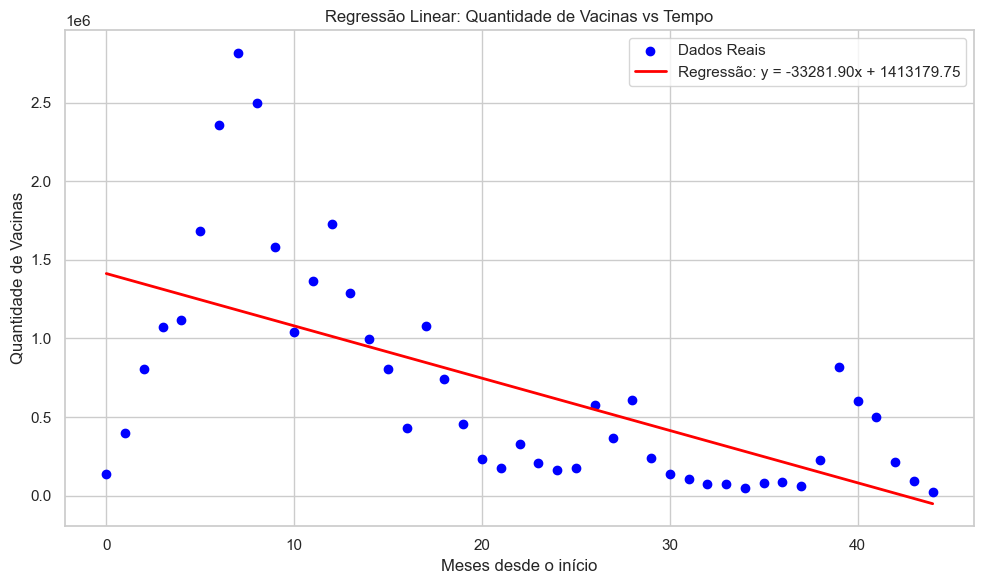

In [5]:
## 1. Preparar os dados para o modelo
X = df_reg["MESES_DESDE_INICIO"].to_numpy().reshape(-1, 1)
y = df_reg["Qtd_Vacinas"].to_numpy()

## 2. Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

inclinacao = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"Equação da reta: Qtd_Vacinas = {inclinacao:.2f} * MESES_DESDE_INICIO + {intercepto:.2f}")
print(f"Coeficiente angular (vacinas/mês): {inclinacao:.2f}")
print(f"Intercepto (quantidade inicial): {intercepto:.2f}")

## 3. Fazer previsões
y_pred = modelo.predict(X)

## 4. Avaliar o modelo
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"\nMétricas de avaliação:")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")

## 5. Visualização dos resultados
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='blue', label='Dados Reais')

plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regressão: y = {inclinacao:.2f}x + {intercepto:.2f}')

plt.title('Regressão Linear: Quantidade de Vacinas vs Tempo')
plt.xlabel('Meses desde o início')
plt.ylabel('Quantidade de Vacinas')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

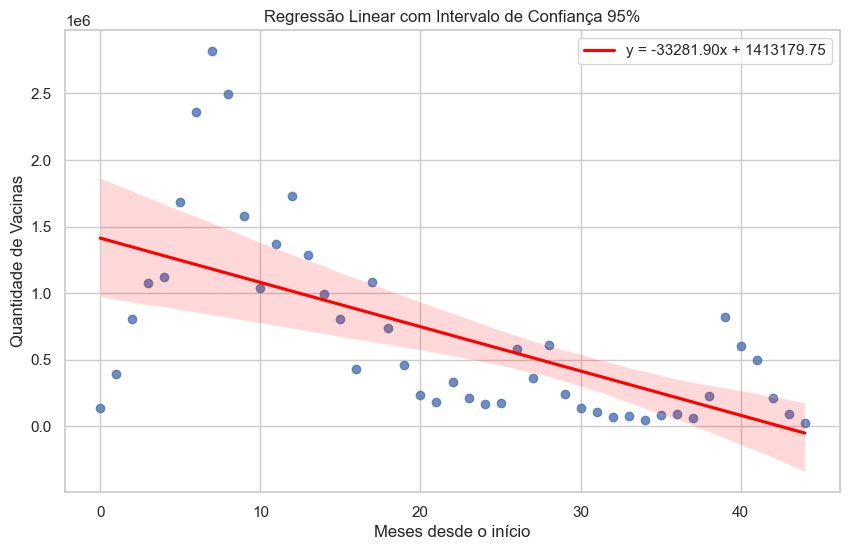

In [6]:
# Versão Alternativa com intervalo de confiança:

plt.figure(figsize=(10, 6))

sns.regplot(
    x=X.flatten(),
    y=y,
    ci=95,
    line_kws={
        'color': 'red',
        'label': f'y = {inclinacao:.2f}x + {intercepto:.2f}'
    }
)

plt.title('Regressão Linear com Intervalo de Confiança 95%')

plt.xlabel('Meses desde o início')

plt.ylabel('Quantidade de Vacinas')

plt.legend()

plt.grid(True)

plt.show()